In [1]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")
pb_rna_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad")    

window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]
base_path = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows"

gene_peaks_neg = {}
for window in window_sizes:
    gene_peaks_neg[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_neg_upst.csv")

gene_peaks_pos = {}
for window in window_sizes:
    gene_peaks_pos[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_pos_downst.csv")

combined_gene_peaks = {}
for window in window_sizes:
    combined_gene_peaks[window] = pd.read_csv(f"{base_path}/combined_gene_peak_assignments_{window}.csv")

In [2]:
pb_atac_ct_time.obs_names.unique().size, pb_rna_ct_time.obs_names.unique().size

(196, 196)

In [3]:
#Substract the genes that are present in the gene_peaks_10kb dataframe from the pb_rna_ct_time dataframe, to only keep the genes that have peaks assigned to them
genes_with_peaks_10kb = gene_peaks_neg["10kb"]["gene_id"].tolist()
pb_rna_ct_time= pb_rna_ct_time[:, genes_with_peaks_10kb] 
print(pb_rna_ct_time.shape)

(196, 19380)


In [4]:
#taking the minimum non-zero value in the pb_rna_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (pb_rna_ct_time.X > 0)
epsilon_rna = np.min(pb_rna_ct_time.X[non_zero_mask])

#taking the minimum non-zero value in the pb_atac_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (pb_atac_ct_time.X > 0)
epsilon_at= np.min(pb_atac_ct_time.X[non_zero_mask])

In [5]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)
pb_atac_ct_time.X = np.log10((pb_atac_ct_time.X+ epsilon_at)*10000000)
print(pb_atac_ct_time.X)
print(pb_rna_ct_time.X)

/tmp/ipykernel_1311620/1176312871.py:3: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)


[[ 0.58441806  0.3880675   1.06160453 ...  0.77350882  4.31687307
   4.26583112]
 [ 0.55057849  0.77497146  1.06311131 ...  0.71223775  4.46490082
   4.42605741]
 [ 0.5812014   0.31814683  1.47411151 ...  0.5812014   4.29971273
   4.26136205]
 ...
 [ 0.68050573  1.00535566  1.21338458 ...  0.87262121  4.28769769
   4.24816241]
 [ 0.56626071  0.77136092  1.20173285 ...  0.96576803  4.32052555
   4.22963983]
 [-0.4579541  -0.4579541   0.93853073 ... -0.4579541   4.43176072
   4.34928772]]
[[4.25576173 2.0227081  1.14233775 ... 1.30666807 2.03139032 3.22471705]
 [4.31351142 2.13705825 1.18129282 ... 1.18129282 1.75880467 3.20162584]
 [4.29089657 2.1197238  0.83199218 ... 1.25890057 1.5464147  3.22147123]
 ...
 [4.48338419 2.30832459 0.04624963 ... 1.67934869 1.93797089 3.48107868]
 [4.44671877 2.3550064  1.73349555 ... 1.6115212  1.44129868 3.40591004]
 [4.45766909 2.4661856  0.04624963 ... 1.63088453 1.75298857 3.42804941]]


In [6]:
print(gene_peaks_neg["5kb"].head())
print(combined_gene_peaks["5kb"].head())

   gene_id                                     assigned_peaks
0    rpl24  ['1-11007-12962', '1-13276-13705', '1-14059-14...
1    cep97                   ['1-9541-9969', '1-11007-12962']
2   nfkbiz  ['1-14059-14260', '1-14625-15105', '1-15724-15...
3      eed                                  ['1-27097-29981']
4  hikeshi  ['1-32151-33568', '1-34134-34335', '1-35228-35...
  gene_id                                     assigned_peaks
0    a1cf  ['12-6176521-6177141', '12-6174866-6175973', '...
1    a2ml  ['15-21132969-21133231', '15-21136218-21136422...
2    aaas             ['9-249047-250089', '9-251006-251939']
3    aacs  ['5-18899208-18900460', '5-18898210-18898918',...
4   aadac  ['15-1076654-1077459', '15-1073465-1074567', '...


# Computing normal OLS on all windows 

In [6]:
#check the maximum number of peaks assigned to each gene in the all windows for both positive and negative windows
import ast
max_peaks_neg = {window: max(gene_peaks_neg[window]['assigned_peaks'].apply(lambda x: len(ast.literal_eval(x)))) for window in window_sizes}
max_peaks_pos = {window: max(gene_peaks_pos[window]['assigned_peaks'].apply(lambda x: len(ast.literal_eval(x)))) for window in window_sizes}
print("Max peaks assigned to a gene in negative windows:", max_peaks_neg)
print("Max peaks assigned to a gene in positive windows:", max_peaks_pos)

#number of samples in the pseudobulk datasets
print(pb_rna_ct_time.n_obs)
print(pb_atac_ct_time.n_obs)

Max peaks assigned to a gene in negative windows: {'5kb': 7, '10kb': 11, '20kb': 18, '30kb': 24, '40kb': 32, '50kb': 38, '60kb': 45, '70kb': 50, '80kb': 58, '90kb': 63, '100kb': 68}
Max peaks assigned to a gene in positive windows: {'5kb': 6, '10kb': 11, '20kb': 18, '30kb': 24, '40kb': 30, '50kb': 37, '60kb': 43, '70kb': 49, '80kb': 54, '90kb': 61, '100kb': 68}
196
196


In [8]:
#computing OLS regression for all positive windows by loading the function from the src folder 
from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)

ols_results_pos = {}
ols_dfs_pos = {}
agg_ols_dfs_pos = {}

gene_peak_dict_pos = {window: gene_peaks_pos[window] for window in window_sizes}

window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

for window in window_label:

    print(f"Computing OLS regression for {window} window...")

    ols_results_pos[window], ols_dfs_pos[window] = compute_peak_gene_ols(
        rna_data=pb_rna_ct_time,
        atac_data=pb_atac_ct_time,
        gene_peaks_df=gene_peak_dict_pos[window],
        window_label=window,
    )

    ols_dfs_pos[window] = classify_peak_gene_pairs(
        ols_dfs_pos[window]
    )

    agg_ols_dfs_pos[window] = aggregate_peak_gene_categories(
        ols_dfs_pos[window]
    )

agg_ols_dfs_pos[window].head()

Computing OLS regression for 5kb window...
[5kb] OLS complete — 19380 genes processed
OLS DataFrame: 29,556 peak–gene pairs
Computing OLS regression for 10kb window...
[10kb] OLS complete — 19380 genes processed
OLS DataFrame: 76,920 peak–gene pairs
Computing OLS regression for 20kb window...
[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 171,825 peak–gene pairs
Computing OLS regression for 30kb window...


KeyboardInterrupt: 

In [96]:
#computing OLS regression for all negative windows by loading the function from the src folder 
from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)

ols_results_neg = {}
ols_dfs_neg = {}
agg_ols_dfs_neg = {}

gene_peak_dict_neg = {window: gene_peaks_neg[window] for window in window_sizes}

window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

for window in window_label:

    print(f"Computing OLS regression for {window} window...")

    ols_results_neg[window], ols_dfs_neg[window] = compute_peak_gene_ols(
        rna_data=pb_rna_ct_time,
        atac_data=pb_atac_ct_time,
        gene_peaks_df=gene_peak_dict_neg[window],
        window_label=window,
    )

    ols_dfs_neg[window] = classify_peak_gene_pairs(
        ols_dfs_neg[window]
    )

    agg_ols_dfs_neg[window] = aggregate_peak_gene_categories(
        ols_dfs_neg[window]
    )

agg_ols_dfs_neg[window].head()

Computing OLS regression for 5kb window...
[5kb] OLS complete — 19380 genes processed
OLS DataFrame: 49,376 peak–gene pairs
Computing OLS regression for 10kb window...
[10kb] OLS complete — 19380 genes processed
OLS DataFrame: 95,089 peak–gene pairs
Computing OLS regression for 20kb window...
[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 188,517 peak–gene pairs
Computing OLS regression for 30kb window...
[30kb] OLS complete — 19380 genes processed
OLS DataFrame: 282,136 peak–gene pairs
Computing OLS regression for 40kb window...
[40kb] OLS complete — 19380 genes processed
OLS DataFrame: 375,238 peak–gene pairs
Computing OLS regression for 50kb window...
[50kb] OLS complete — 19380 genes processed
OLS DataFrame: 468,242 peak–gene pairs
Computing OLS regression for 60kb window...
[60kb] OLS complete — 19380 genes processed
OLS DataFrame: 561,612 peak–gene pairs
Computing OLS regression for 70kb window...
[70kb] OLS complete — 19380 genes processed
OLS DataFrame: 654,285 peak

,window,gene,category,count
0,100kb,a1cf,non-significant,45
1,100kb,a1cf,sig. negative,2
2,100kb,a1cf,sig. positive,1
3,100kb,a2ml,non-significant,33
4,100kb,a2ml,sig. negative,1


In [7]:
#computing OLS regression for all combined windows by loading the function from the src folder 
from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)

ols_results_combined = {}
ols_dfs_combined = {}
agg_ols_dfs_combined = {}

gene_peak_dict_combined = {window: combined_gene_peaks[window] for window in window_sizes}

window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

for window in window_label:

    print(f"Computing OLS regression for {window} window...")

    ols_results_combined[window], ols_dfs_combined[window] = compute_peak_gene_ols(
        rna_data=pb_rna_ct_time,
        atac_data=pb_atac_ct_time,
        gene_peaks_df=gene_peak_dict_combined[window],
        window_label=window,
    )

    ols_dfs_combined[window] = classify_peak_gene_pairs(
        ols_dfs_combined[window]
    )

    agg_ols_dfs_combined[window] = aggregate_peak_gene_categories(
        ols_dfs_combined[window]
    )

agg_ols_dfs_combined[window].head()



Computing OLS regression for 5kb window...
[5kb] OLS complete — 19380 genes processed
OLS DataFrame: 78,930 peak–gene pairs
Computing OLS regression for 10kb window...
[10kb] OLS complete — 19380 genes processed
OLS DataFrame: 172,007 peak–gene pairs
Computing OLS regression for 20kb window...
[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 360,340 peak–gene pairs
Computing OLS regression for 30kb window...
[30kb] OLS complete — 19380 genes processed
OLS DataFrame: 548,586 peak–gene pairs
Computing OLS regression for 40kb window...
[40kb] OLS complete — 19380 genes processed
OLS DataFrame: 735,882 peak–gene pairs
Computing OLS regression for 50kb window...
[50kb] OLS complete — 19380 genes processed
OLS DataFrame: 922,652 peak–gene pairs
Computing OLS regression for 60kb window...
[60kb] OLS complete — 19380 genes processed
OLS DataFrame: 1,109,615 peak–gene pairs
Computing OLS regression for 70kb window...
[70kb] OLS complete — 19380 genes processed
OLS DataFrame: 1,295,744

,window,gene,category,count
0,100kb,a1cf,non-significant,89
1,100kb,a1cf,sig. negative,2
2,100kb,a1cf,sig. positive,4
3,100kb,a2ml,non-significant,77
4,100kb,aaas,non-significant,102


In [8]:
#combine all ols of combined windows into one dataframe
all_combined_ols_df = pd.concat(
    [df.assign(window=window) for window, df in ols_dfs_combined.items()],
    ignore_index=True
)

all_combined_ols_df.head()

all_combined_ols_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv", index=False)

In [11]:
#combine all the ols_dfs for both positive and negative windows into a single dataframe for downstream analysis and visualization
all_ols_neg_df = pd.concat(
    [df.assign(window=window) for window, df in ols_dfs_neg.items()],
    ignore_index=True
)

all_ols_pos_df = pd.concat(
    [df.assign(window=window) for window, df in ols_dfs_pos.items()],
    ignore_index=True
)

all_ols_combined_df = pd.concat(
    [all_ols_neg_df.assign(direction="neg"),
     all_ols_pos_df.assign(direction="pos")],
    ignore_index=True
)

#save the all_ols_dfs dataframe to a csv file for downstream analysis and visualization
all_ols_neg_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_neg_df_ct_time.csv", index=False)
all_ols_pos_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_pos_df_ct_time.csv", index=False)
all_ols_combined_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_combined_df_ct_time.csv", index=False)

In [153]:
#sanity check to confirm that the ols.function computes the same results as the OLS regression loop for the 10kb window
ols_all_df_neg[ols_all_df_neg["window"] == "10kb"].head()

,window,gene,peak,coef,pval,category
49376,10kb,rpl24,1-11007-12962,0.024287,0.074037,non-significant
49377,10kb,rpl24,1-13276-13705,-0.012074,0.307997,non-significant
49378,10kb,rpl24,1-14059-14260,-0.002477,0.884627,non-significant
49379,10kb,rpl24,1-14625-15105,-0.022161,0.140598,non-significant
49380,10kb,rpl24,1-15724-15934,0.012749,0.251126,non-significant


In [159]:
#check the total number of unique gene/peak pairs in the 10kb window for the negative window dataframe
print("Total unique gene/peak pairs in 10kb window (negative):", ols_all_df_neg[ols_all_df_neg["window"] == "10kb"][["gene", "peak"]].drop_duplicates().shape[0])
print("Total unique gene/peak  pairs in 10kb nega. window dataframe:", len(ols_res_10kb_df.groupby(["gene", "peak"])))

Total unique gene/peak pairs in 10kb window (negative): 95089
Total unique gene/peak  pairs in 10kb nega. window dataframe: 95089


## Plotting the OLS results

In [1]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
import pandas as pd
ols_all_df_neg = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_neg_df_ct_time.csv")
ols_all_df_pos = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_pos_df_ct_time.csv")

#aggregate the number of significant peaks per gene and category  
agg_ols_all_df_pos = (
    ols_all_df_pos
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_ols_all_df_neg = (
    ols_all_df_neg
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

In [176]:
print(agg_ols_all_df_pos.head())
print(agg_ols_all_df_neg.head())

  window  gene         category  count
0  100kb  a1cf  non-significant     45
1  100kb  a1cf    sig. negative      1
2  100kb  a1cf    sig. positive      1
3  100kb  a2ml  non-significant     37
4  100kb  a2ml    sig. negative      3
  window  gene         category  count
0  100kb  a1cf  non-significant     45
1  100kb  a1cf    sig. negative      2
2  100kb  a1cf    sig. positive      1
3  100kb  a2ml  non-significant     33
4  100kb  a2ml    sig. negative      1


In [177]:
#count the total unique gene/peak pairs in the all_ols_dfs dataframe
total_unique_gene_peak_pairs = ols_all_df_pos[["gene", "peak"]].drop_duplicates().shape[0]
print("Total unique gene/peak pairs in pos. window:", total_unique_gene_peak_pairs)

total_unique_gene_peak_pairs = ols_all_df_neg[["gene", "peak"]].drop_duplicates().shape[0]
print("Total unique gene/peak pairs in neg. window:", total_unique_gene_peak_pairs)

Total unique gene/peak pairs in pos. window: 920896
Total unique gene/peak pairs in neg. window: 932635


In [3]:
#merge the aggregated dataframes for positive and negative windows to compare the number of significant peaks per gene and category across windows
agg_ols_all_df_combined = pd.concat(
    [agg_ols_all_df_neg.assign(direction="neg"),
     agg_ols_all_df_pos.assign(direction="pos")],
    ignore_index=True
)
agg_ols_all_df_combined.head()

,window,gene,category,count,direction
0,100kb,a1cf,non-significant,45,neg
1,100kb,a1cf,sig. negative,2,neg
2,100kb,a1cf,sig. positive,1,neg
3,100kb,a2ml,non-significant,33,neg
4,100kb,a2ml,sig. negative,1,neg


In [124]:
#counting the number of significant peaks per gene and category across windows for both positive and negative windows
significant_peaks_count = agg_ols_all_df_combined.groupby(["window","category", "direction", "count"]).size().reset_index(name="total_genes")
significant_peaks_count.head()

,window,category,direction,count,total_genes
0,100kb,non-significant,neg,1,13
1,100kb,non-significant,neg,2,8
2,100kb,non-significant,neg,3,17
3,100kb,non-significant,neg,4,14
4,100kb,non-significant,neg,5,12


In [125]:
#creat a order column to the combined aggregated dataframe for better visualization of the windows direction
#Creat a chromosome number column by first sorting the chr column and then adding a number starting from 1 for the first unique chromosome and incrementing by 1 for each subsequent unique chromosome
import numpy as np

# Define the desired window order explicitly if needed
window_order = window_sizes  # This will maintain the order as defined in the window_sizes list

significant_peaks_count["window"] = pd.Categorical(
    significant_peaks_count["window"],
    categories=window_order,
    ordered=True
)

window_codes = significant_peaks_count["window"].cat.codes + 1

significant_peaks_count["window_order"] = np.where(
    significant_peaks_count["direction"] == "pos",
    window_codes,
    -window_codes
)

significant_peaks_count.head()

,window,category,direction,count,total_genes,window_order
0,100kb,non-significant,neg,1,13,-11
1,100kb,non-significant,neg,2,8,-11
2,100kb,non-significant,neg,3,17,-11
3,100kb,non-significant,neg,4,14,-11
4,100kb,non-significant,neg,5,12,-11


In [126]:
#sanity check: count the number of genes with this condition 
agg_ols_all_df_combined.loc[
    (agg_ols_all_df_combined["window"] == "5kb") &
    (agg_ols_all_df_combined["category"] == "non-significant") &
    (agg_ols_all_df_combined["direction"] == "neg") &
    (agg_ols_all_df_combined["count"] == 1),
    "gene"
].nunique()

3306

In [127]:
#calculate the fraction of total_genes within one category and window by dividing the total_genes by the total number of unique genes in that window and category across both directions
significant_peaks_count["fraction"] = (
    significant_peaks_count["total_genes"]
    / significant_peaks_count.groupby(
        ["window", "window_order", "category"]
    )["total_genes"].transform("sum")
)

significant_peaks_count.head()

/tmp/ipykernel_961607/3557555073.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / significant_peaks_count.groupby(


,window,category,direction,count,total_genes,window_order,fraction
0,100kb,non-significant,neg,1,13,-11,0.000678
1,100kb,non-significant,neg,2,8,-11,0.000418
2,100kb,non-significant,neg,3,17,-11,0.000887
3,100kb,non-significant,neg,4,14,-11,0.000731
4,100kb,non-significant,neg,5,12,-11,0.000626


In [128]:
#Add window_label column for 5kb window it should be labled TSS+5kb, for 10kb it should be TSS+10kb and so on for all windows if the direction is pos, if direction is neg, it should be labeled TSS-5kb for 5kb window, TSS+10kb for 10kb window and so on for all windows
significant_peaks_count["window_label"] = significant_peaks_count.apply(
    lambda row: f"TSS+{row['window']}" if row["direction"] == "pos" else f"TSS-{row['window']}",
    axis=1
)
significant_peaks_count.head()


,window,category,direction,count,total_genes,window_order,fraction,window_label
0,100kb,non-significant,neg,1,13,-11,0.000678,TSS-100kb
1,100kb,non-significant,neg,2,8,-11,0.000418,TSS-100kb
2,100kb,non-significant,neg,3,17,-11,0.000887,TSS-100kb
3,100kb,non-significant,neg,4,14,-11,0.000731,TSS-100kb
4,100kb,non-significant,neg,5,12,-11,0.000626,TSS-100kb


In [129]:
#sort the dataframe by the window_order column to ensure the windows are in the correct order for visualization
significant_peaks_count = significant_peaks_count.sort_values("window_order")
significant_peaks_count.head()

,window,category,direction,count,total_genes,window_order,fraction,window_label
0,100kb,non-significant,neg,1,13,-11,0.000678,TSS-100kb
61,100kb,non-significant,neg,62,16,-11,0.000835,TSS-100kb
60,100kb,non-significant,neg,61,29,-11,0.001514,TSS-100kb
59,100kb,non-significant,neg,60,46,-11,0.002401,TSS-100kb
58,100kb,non-significant,neg,59,63,-11,0.003288,TSS-100kb


In [100]:
#sanity check: confirm that the fraction column sums to 1 for each window and category across both directions
fraction_sums = significant_peaks_count.groupby(["window_order", "category"])["fraction"].sum().reset_index()
print(fraction_sums[fraction_sums["fraction"] != 1.0])

    window_order         category  fraction
8             -9    sig. positive       1.0
36             2  non-significant       1.0


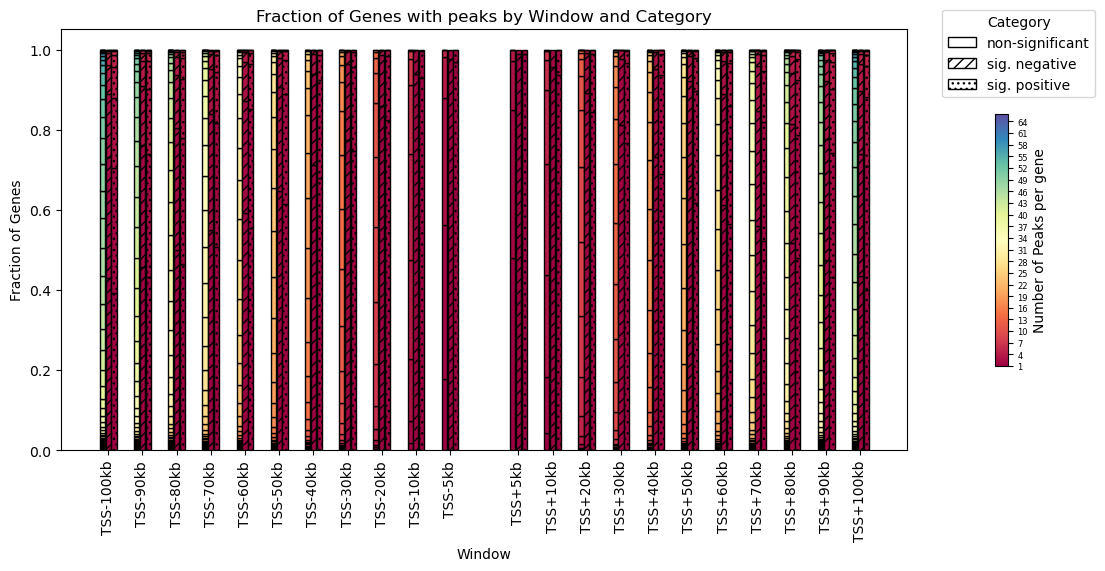

In [173]:
#visualize the fraction of genes with significant peaks by window and category using a stacked bar plot, where the x-axis represents the windows, the y-axis represents the fraction of genes, and the bars are colored by category. The color intensity of the bars will represent the count of significant peaks per gene, with a color gradient from light to dark blue indicating low to high counts. Additionally, we will use different hatching patterns to distinguish between categories, and include a legend to indicate which pattern corresponds to which category.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# use raw df — no aggregation, keep individual count rows
plot_df = significant_peaks_count.copy()

windows = plot_df['window_label'].unique()  # e.g. ['5kb', '10kb', '20kb', '50kb', '100kb']
categories = sorted(plot_df['category'].unique())
n_cats = len(categories)
n_windows = len(windows)

count_min = plot_df['count'].min()
count_max = plot_df['count'].max()
norm = mcolors.Normalize(vmin=count_min, vmax=count_max)
cmap = cm.Spectral  

bar_width = 0.15
#x_positions should be in the order of the window_order column, which is already sorted in the significant_peaks_count dataframe
x_positions = sorted(plot_df['window_order'].unique())

offsets = np.linspace(-(n_cats - 1) / 2, (n_cats - 1) / 2, n_cats) * (bar_width + 0.02)
hatches = ['', '///', '...']
fig, ax = plt.subplots(figsize=(12, 6))
for i, category in enumerate(categories):
    cat_data = plot_df[plot_df['category'] == category]

    for j, window in enumerate(windows):
        win_cat_data = cat_data[cat_data['window_label'] == window]

        if win_cat_data.empty:
            continue

        #enforce LOW → HIGH stacking order
        win_cat_data = win_cat_data.sort_values('count', ascending=True)

        x_pos = x_positions[j] + offsets[i]

        total = win_cat_data['fraction'].sum()
        bottom = 0

        for _, row in win_cat_data.iterrows():
            frac = row['fraction'] / total

            ax.bar(
                x_pos,
                frac,
                width=bar_width,
                bottom=bottom,
                color=cmap(norm(row['count'])),  # consistent with colormap
                edgecolor='black',
                hatch=hatches[i],
                label=category if (j == 0 and bottom == 0) else ""
            )

            bottom += frac
#labeling the colorbar with the count values
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label='Number of Peaks per gene')  # Add label to colorbar
cbar.set_ticks(np.arange(count_min, count_max, 3))
cbar.ax.tick_params(labelsize=6)  # Set ticks at integer values with a step of 2, adjust as needed
# Get colorbar position in figure coordinates
cbar_pos = cbar.ax.get_position()

ax.set_xticks(x_positions)
ax.set_xticklabels(windows, rotation=90)
ax.set_xlabel('Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes with peaks by Window and Category')
handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=categories[i]) for i in range(n_cats)]
ax.legend(handles=handles, title='Category', loc ='lower left', bbox_to_anchor=(cbar_pos.x0, cbar_pos.y1 +0.06), bbox_transform=fig.transFigure) #positioning the legend outside the plot area to avoid overlapping with the bars
plt.tight_layout()
plt.show()

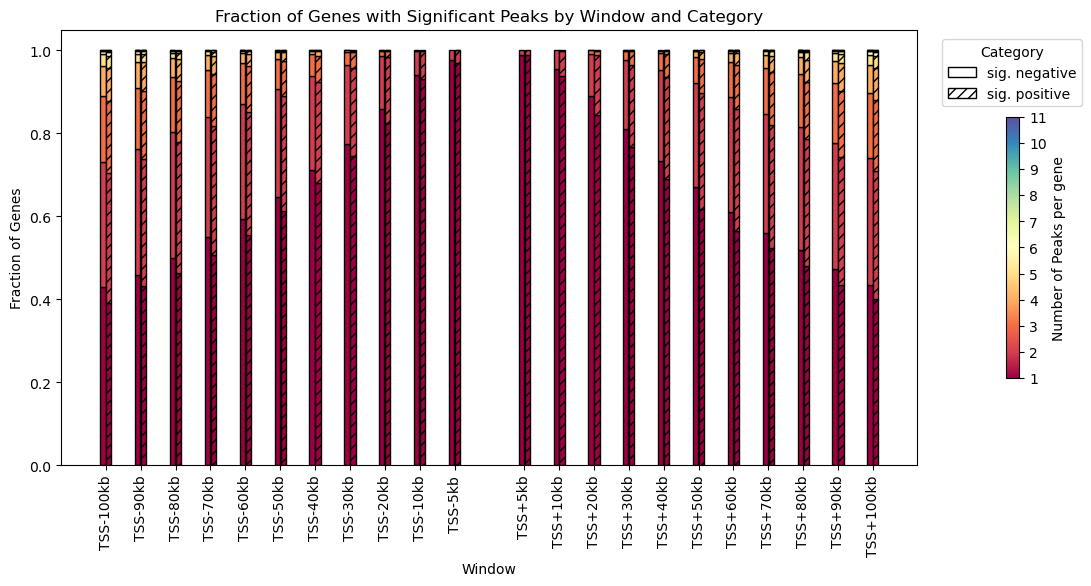

In [ ]:
#visualize the fraction of genes with significant peaks by window and category using a stacked bar plot, where the x-axis represents the windows, the y-axis represents the fraction of genes, and the bars are colored by category. The color intensity of the bars will represent the count of significant peaks per gene, with a color gradient from light to dark blue indicating low to high counts. Additionally, we will use different hatching patterns to distinguish between categories, and include a legend to indicate which pattern corresponds to which category.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# use raw df — no aggregation, keep individual count rows
plot_df_non = significant_peaks_count[significant_peaks_count['category'] != "non-significant"].copy()

windows = plot_df_non['window_label'].unique()  # e.g. ['5kb', '10kb', '20kb', '50kb', '100kb']
categories = sorted(plot_df_non['category'].unique())
n_cats = len(categories)
n_windows = len(windows)

count_min = plot_df_non['count'].min()
count_max = plot_df_non['count'].max()
norm = mcolors.Normalize(vmin=count_min, vmax=count_max)
cmap = cm.Spectral  

bar_width = 0.15
#x_positions should be in the order of the window_order column, which is already sorted in the significant_peaks_count dataframe
x_positions = sorted(plot_df_non['window_order'].unique())

offsets = np.linspace(-(n_cats - 1) / 2, (n_cats - 1) / 2, n_cats) * (bar_width + 0.02)
hatches = ['', '///', '...']
fig, ax = plt.subplots(figsize=(12, 6))
for i, category in enumerate(categories):
    cat_data = plot_df_non[plot_df_non['category'] == category]

    for j, window in enumerate(windows):
        win_cat_data = cat_data[cat_data['window_label'] == window]

        if win_cat_data.empty:
            continue

        #enforce LOW → HIGH stacking order
        win_cat_data = win_cat_data.sort_values('count', ascending=True)

        x_pos = x_positions[j] + offsets[i]

        total = win_cat_data['fraction'].sum()
        bottom = 0

        for _, row in win_cat_data.iterrows():
            frac = row['fraction'] / total

            ax.bar(
                x_pos,
                frac,
                width=bar_width,
                bottom=bottom,
                color=cmap(norm(row['count'])),  # consistent with colormap
                edgecolor='black',
                hatch=hatches[i],
                label=category if (j == 0 and bottom == 0) else ""
            )

            bottom += frac
#labeling the colorbar with the count values
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label='Number of Peaks per gene')  # Add label to colorbar
cbar.set_ticks(np.arange(count_min, count_max + 1, 1))

# Get colorbar position in figure coordinates
cbar_pos = cbar.ax.get_position()

ax.set_xticks(x_positions)
ax.set_xticklabels(windows, rotation=90)
ax.set_xlabel('Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes with Significant Peaks by Window and Category')
handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=categories[i]) for i in range(n_cats)]
ax.legend(handles=handles, title='Category', loc ='lower left', bbox_to_anchor=(cbar_pos.x0, cbar_pos.y1 +0.07), bbox_transform=fig.transFigure) #positioning the legend outside the plot area to avoid overlapping with the bars
plt.tight_layout()
plt.show()

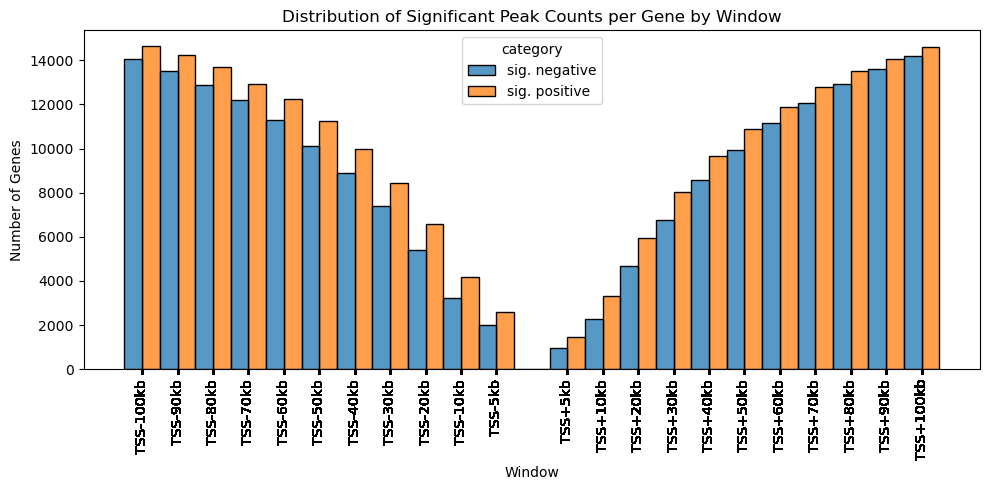

In [ ]:
# plot the significant peak counts across all genes for the all windows using seaborn histplot, with separate colors for sig. positive and sig. negative categories
import matplotlib.pyplot as plt
import seaborn as sns

agg_ols_all_df_combined["window"] = pd.Categorical(
    agg_ols_all_df_combined["window"],
    categories=window_order,
    ordered=True
)

window_codes = agg_ols_all_df_combined["window"].cat.codes + 1

agg_ols_all_df_combined["window_order"] = np.where(
    agg_ols_all_df_combined["direction"] == "pos",
    window_codes,
    -window_codes
)
agg_ols_all_df_combined["window_label"] = agg_ols_all_df_combined.apply(
    lambda row: f"TSS+{row['window']}" if row["direction"] == "pos" else f"TSS-{row['window']}",
    axis=1
)

category_order = ["sig. negative", "sig. positive"]
agg_ols_all_df_combined_non = agg_ols_all_df_combined[agg_ols_all_df_combined["category"] != "non-significant"].copy()
x_positions = agg_ols_all_df_combined_non['window_order'].values
x_labels = agg_ols_all_df_combined_non['window_label'].values

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=agg_ols_all_df_combined_non,
    x="window_order",
    hue="category",
    hue_order=["sig. negative", "sig. positive"],
    multiple="dodge",
    discrete=True,
    ax=ax
)

ax.set_xlabel("Window")
ax.set_ylabel("Number of Genes")
ax.set_title("Distribution of Significant Peak Counts per Gene by Window")

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=90)

plt.tight_layout()
plt.show()

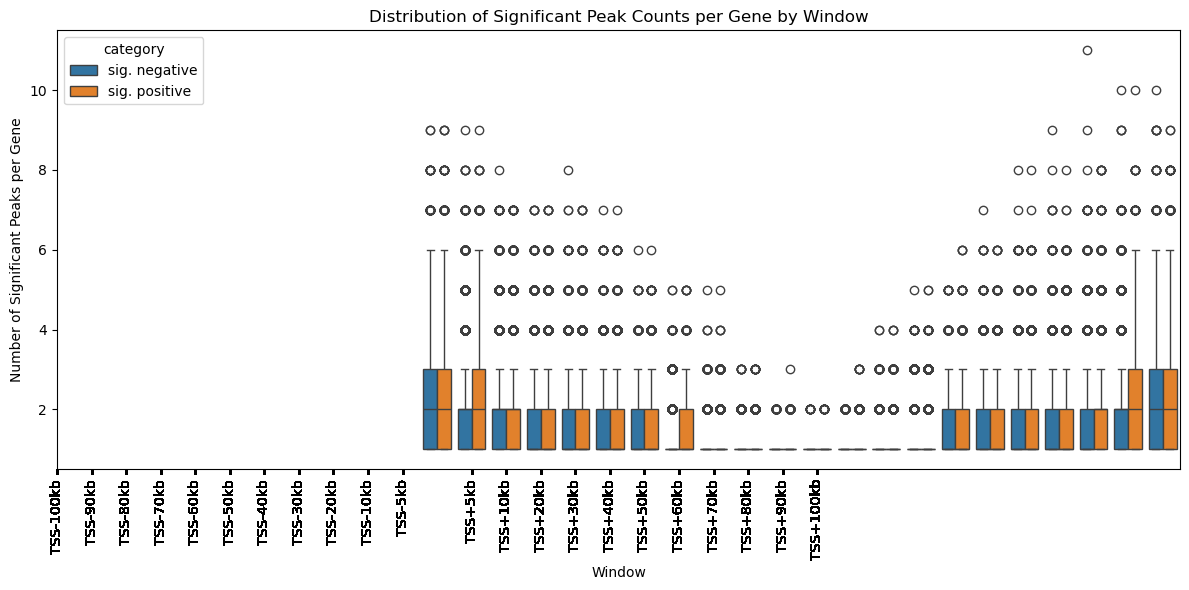

In [ ]:
#boxplot of the distribution of significant peak counts per gene by window and category

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

window_order =  ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]  # This will maintain the order as defined in the window_sizes list
agg_ols_all_df_combined["window"] = pd.Categorical(
    agg_ols_all_df_combined["window"],
    categories=window_order,
    ordered=True
)

window_codes = agg_ols_all_df_combined["window"].cat.codes + 1

agg_ols_all_df_combined["window_order"] = np.where(
    agg_ols_all_df_combined["direction"] == "pos",
    window_codes,
    -window_codes
)

agg_ols_all_df_combined["window_label"] = agg_ols_all_df_combined.apply(
    lambda row: f"TSS+{row['window']}" if row["direction"] == "pos" else f"TSS-{row['window']}",
    axis=1
)

# filter non-significant
df = agg_ols_all_df_combined[
    agg_ols_all_df_combined["category"] != "non-significant"
].copy()

# build ordered label list: TSS-100kb ... TSS-5kb, TSS+5kb ... TSS+100kb
neg_labels = [f"TSS-{w}" for w in reversed(window_order)]
pos_labels = [f"TSS+{w}" for w in window_order]
label_order = neg_labels + pos_labels

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="window_label",
    y="count",
    hue="category",
    hue_order=["sig. negative", "sig. positive"],
    order=label_order,
    ax=ax
)
ax.set_xlabel("Window")
ax.set_ylabel("Number of Significant Peaks per Gene")
ax.set_title("Distribution of Significant Peak Counts per Gene by Window")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1018768/976338252.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


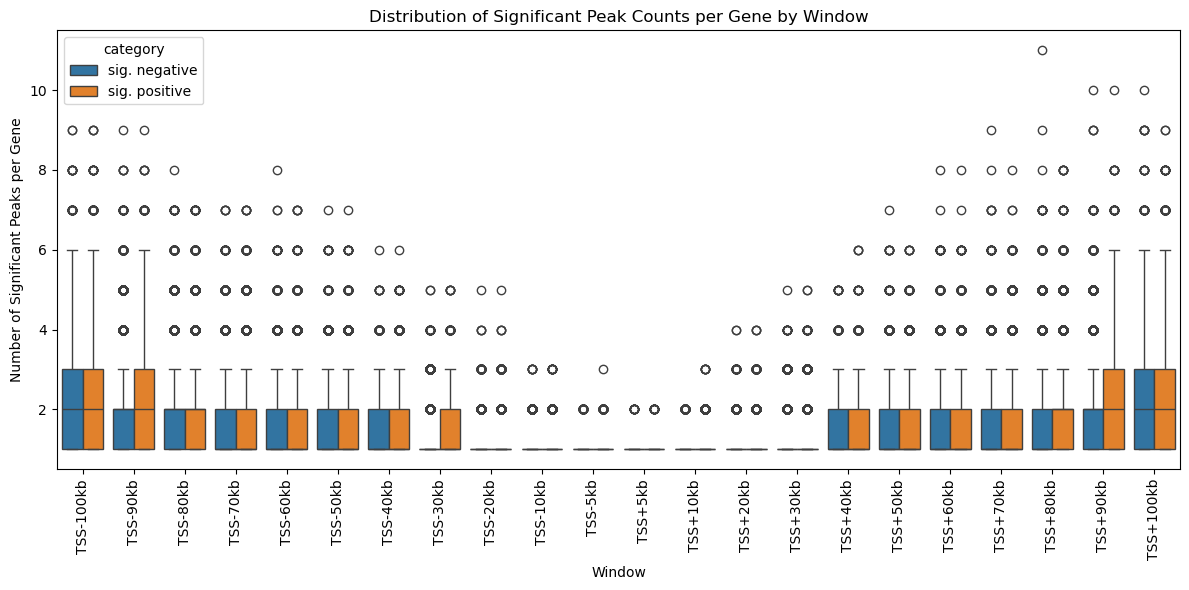

In [11]:
# build ordered label list: TSS-100kb ... TSS-5kb, TSS+5kb ... TSS+100kb
neg_labels = [f"TSS-{w}" for w in reversed(window_order)]
pos_labels = [f"TSS+{w}" for w in window_order]
label_order = neg_labels + pos_labels

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="window_label",
    y="count",
    hue="category",
    hue_order=["sig. negative", "sig. positive"],
    order=label_order,
    ax=ax
)
ax.set_xlabel("Window")
ax.set_ylabel("Number of Significant Peaks per Gene")
ax.set_title("Distribution of Significant Peak Counts per Gene by Window")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

In [199]:
agg_ols_all_df_combined_non

,window,gene,category,count,direction,window_order,window_label
1,100kb,a1cf,sig. negative,2,neg,11,TSS-100kb
2,100kb,a1cf,sig. positive,1,neg,11,TSS-100kb
4,100kb,a2ml,sig. negative,1,neg,11,TSS-100kb
6,100kb,aaas,sig. negative,2,neg,11,TSS-100kb
7,100kb,aaas,sig. positive,3,neg,11,TSS-100kb
...,...,...,...,...,...,...,...
831931,90kb,zyg11,sig. positive,2,pos,10,TSS+90kb
831933,90kb,zyx,sig. negative,1,pos,10,TSS+90kb
831934,90kb,zyx,sig. positive,4,pos,10,TSS+90kb
831936,90kb,zzef1,sig. negative,3,pos,10,TSS+90kb


## Deduplication

In [13]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
import pandas as pd
window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

ols_all_df = {
    "neg": pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_neg_df_ct_time.csv"),
    "pos": pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_pos_df_ct_time.csv")
}

directions = ["pos", "neg"]

# Make window categorical and ordered
for dir in directions:
    ols_all_df[dir]["window"] = pd.Categorical(
        ols_all_df[dir]["window"],
        categories=window_label,
        ordered=True
    )
    ols_all_df[dir] = ols_all_df[dir].sort_values("window", ascending=True)

print(ols_all_df["neg"][["window", "gene", "peak", "coef", "pval", "category"]].head())

# Deduplicate gene-peak pairs, keeping smallest window size
pair_summary = {}
for dir in directions:
    pair_summary[dir] = (
        ols_all_df[dir]
        .groupby(["gene", "peak"], as_index=False)
        .first()
        .sort_values("window", ascending=True)
    )

print(pair_summary["neg"][["window", "gene", "peak", "coef", "pval", "category"]].head())

# Sanity check: each gene-peak pair should appear exactly once
for dir in directions:
    pair_counts = pair_summary[dir].groupby(["gene", "peak"]).size().reset_index(name="count")
    print(f"{dir}: ", pair_counts["count"].value_counts())

# Count unique gene-peak pairs per category per window
summary_counts = {}
for dir in directions:
    summary_counts[dir] = (
        pair_summary[dir]
        .groupby(["window", "gene", "category"])
        .size()
        .reset_index(name="count")
    )

print(summary_counts["neg"].head())

      window            gene                  peak      coef      pval  \
0        5kb           rpl24         1-11007-12962  0.018641  0.126230   
32911    5kb  si:dkey-7j14.6  16-43040575-43041606 -0.006571  0.430712   
32912    5kb         rundc3b  16-43076783-43078453  0.035518  0.425856   
32913    5kb        slc25a40  16-43138530-43140220  0.004029  0.749561   
32914    5kb        slc25a40  16-43142633-43142926  0.006681  0.596612   

              category  
0      non-significant  
32911  non-significant  
32912  non-significant  
32913  non-significant  
32914  non-significant  
       window  gene                  peak      coef      pval         category
0         5kb  a1cf    12-6177594-6178380 -0.011927  0.761092  non-significant
342471    5kb  iqcg  18-27904091-27905066 -0.062491  0.146163  non-significant
342470    5kb  iqcg  18-27903105-27903641  0.049054  0.256808  non-significant
342427    5kb  iqce   1-11882239-11882580 -0.018827  0.256065  non-significant
342426    

/tmp/ipykernel_1018768/4268516300.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene", "category"])
/tmp/ipykernel_1018768/4268516300.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene", "category"])


  window  gene         category  count
0    5kb  a1cf  non-significant      3
1    5kb  a1cf    sig. negative      0
2    5kb  a1cf    sig. positive      0
3    5kb  a2ml  non-significant      4
4    5kb  a2ml    sig. negative      0


In [14]:
#merge the aggregated dataframes for positive and negative windows to compare the number of significant peaks per gene and category across windows
combined_summary = pd.concat(
    [summary_counts["neg"].assign(direction="neg"),
     summary_counts["pos"].assign(direction="pos")],
    ignore_index=True
)
combined_summary.head()

,window,gene,category,count,direction
0,5kb,a1cf,non-significant,3,neg
1,5kb,a1cf,sig. negative,0,neg
2,5kb,a1cf,sig. positive,0,neg
3,5kb,a2ml,non-significant,4,neg
4,5kb,a2ml,sig. negative,0,neg


/tmp/ipykernel_1018768/1399500106.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


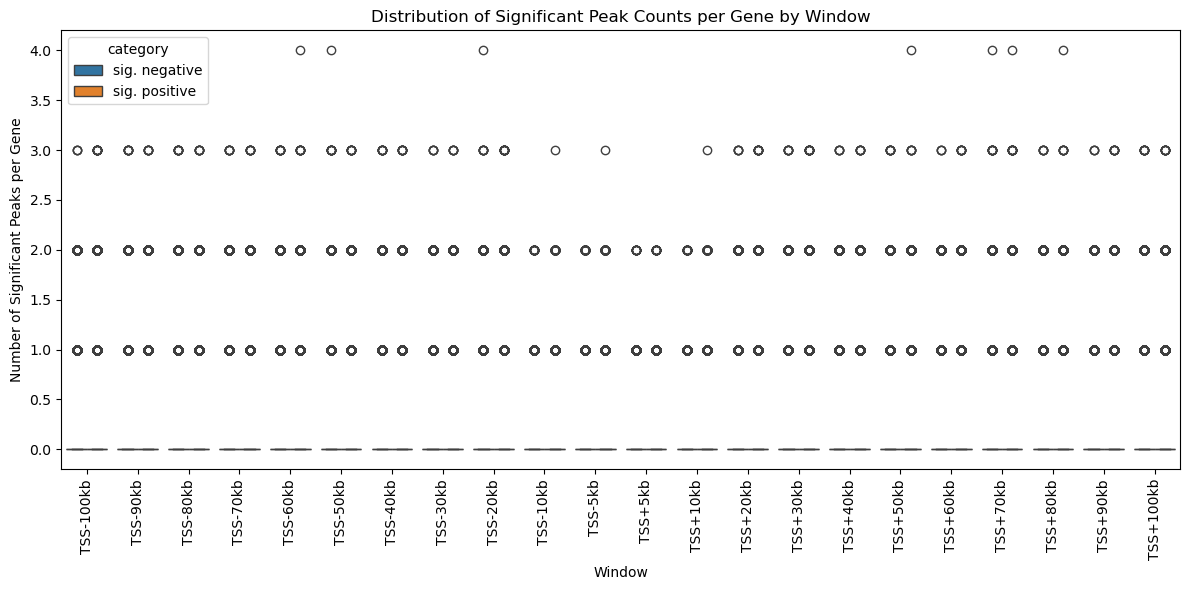

In [15]:
#boxplot of the distribution of deduplicated significant peak counts per gene by window and category

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

window_order =  ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]  # This will maintain the order as defined in the window_sizes list
combined_summary["window"] = pd.Categorical(
    combined_summary["window"],
    categories=window_order,
    ordered=True
)

window_codes = combined_summary["window"].cat.codes + 1

combined_summary["window_order"] = np.where(
    combined_summary["direction"] == "pos",
    window_codes,
    -window_codes
)

combined_summary["window_label"] = combined_summary.apply(
    lambda row: f"TSS+{row['window']}" if row["direction"] == "pos" else f"TSS-{row['window']}",
    axis=1
)

# filter non-significant
df = combined_summary[
    combined_summary["category"] != "non-significant"
].copy()

# build ordered label list: TSS-100kb ... TSS-5kb, TSS+5kb ... TSS+100kb
neg_labels = [f"TSS-{w}" for w in reversed(window_order)]
pos_labels = [f"TSS+{w}" for w in window_order]
label_order = neg_labels + pos_labels

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="window_label",
    y="count",
    hue="category",
    hue_order=["sig. negative", "sig. positive"],
    order=label_order,
    ax=ax
)
ax.set_xlabel("Window")
ax.set_ylabel("Number of Significant Peaks per Gene")
ax.set_title("Distribution of Significant Peak Counts per Gene by Window")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#visualize the fraction of genes with significant peaks by window and category using a stacked bar plot, where the x-axis represents the windows, the y-axis represents the fraction of genes, and the bars are colored by category. The color intensity of the bars will represent the count of significant peaks per gene, with a color gradient from light to dark blue indicating low to high counts. Additionally, we will use different hatching patterns to distinguish between categories, and include a legend to indicate which pattern corresponds to which category.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# use raw df — no aggregation, keep individual count rows
plot_df_non = significant_peaks_count[significant_peaks_count['category'] != "non-significant"].copy()

windows = plot_df_non['window_label'].unique()  # e.g. ['5kb', '10kb', '20kb', '50kb', '100kb']
categories = sorted(plot_df_non['category'].unique())
n_cats = len(categories)
n_windows = len(windows)

count_min = plot_df_non['count'].min()
count_max = plot_df_non['count'].max()
norm = mcolors.Normalize(vmin=count_min, vmax=count_max)
cmap = cm.Spectral  

bar_width = 0.15
#x_positions should be in the order of the window_order column, which is already sorted in the significant_peaks_count dataframe
x_positions = sorted(plot_df_non['window_order'].unique())

offsets = np.linspace(-(n_cats - 1) / 2, (n_cats - 1) / 2, n_cats) * (bar_width + 0.02)
hatches = ['', '///', '...']
fig, ax = plt.subplots(figsize=(12, 6))
for i, category in enumerate(categories):
    cat_data = plot_df_non[plot_df_non['category'] == category]

    for j, window in enumerate(windows):
        win_cat_data = cat_data[cat_data['window_label'] == window]

        if win_cat_data.empty:
            continue

        #enforce LOW → HIGH stacking order
        win_cat_data = win_cat_data.sort_values('count', ascending=True)

        x_pos = x_positions[j] + offsets[i]

        total = win_cat_data['fraction'].sum()
        bottom = 0

        for _, row in win_cat_data.iterrows():
            frac = row['fraction'] / total

            ax.bar(
                x_pos,
                frac,
                width=bar_width,
                bottom=bottom,
                color=cmap(norm(row['count'])),  # consistent with colormap
                edgecolor='black',
                hatch=hatches[i],
                label=category if (j == 0 and bottom == 0) else ""
            )

            bottom += frac
#labeling the colorbar with the count values
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label='Number of Peaks per gene')  # Add label to colorbar
cbar.set_ticks(np.arange(count_min, count_max + 1, 1))

# Get colorbar position in figure coordinates
cbar_pos = cbar.ax.get_position()

ax.set_xticks(x_positions)
ax.set_xticklabels(windows, rotation=90)
ax.set_xlabel('Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes with Significant Peaks by Window and Category')
handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=categories[i]) for i in range(n_cats)]
ax.legend(handles=handles, title='Category', loc ='lower left', bbox_to_anchor=(cbar_pos.x0, cbar_pos.y1 +0.07), bbox_transform=fig.transFigure) #positioning the legend outside the plot area to avoid overlapping with the bars
plt.tight_layout()
plt.show()

# sanity check of deduplication code

In [9]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
import pandas as pd
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_neg_df_ct_time.csv")
print(ols_all_df.head())

# Make window categorical and ordered
ols_all_df["window"] = pd.Categorical(
    ols_all_df["window"],
    categories=[window for window in window_label],
    ordered=True
)

ols_all_df.head()

  window   gene           peak      coef      pval         category
0    5kb  rpl24  1-11007-12962  0.018641  0.126230  non-significant
1    5kb  rpl24  1-13276-13705 -0.008529  0.456906  non-significant
2    5kb  rpl24  1-14059-14260 -0.005875  0.714421  non-significant
3    5kb  rpl24  1-14625-15105 -0.023346  0.102244  non-significant
4    5kb  rpl24  1-15724-15934  0.012797  0.235015  non-significant


NameError: name 'window_label' is not defined

In [ ]:
# Order by window
ols_all_df = ols_all_df.sort_values("window",ascending=True)
print(ols_all_df[["window", "gene", "peak", "coef", "pval", "category"]].head())



      window            gene                  peak      coef      pval  \
0        5kb           rpl24         1-11007-12962  0.018641  0.126230   
32911    5kb  si:dkey-7j14.6  16-43040575-43041606 -0.006571  0.430712   
32912    5kb         rundc3b  16-43076783-43078453  0.035518  0.425856   
32913    5kb        slc25a40  16-43138530-43140220  0.004029  0.749561   
32914    5kb        slc25a40  16-43142633-43142926  0.006681  0.596612   

              category  
0      non-significant  
32911  non-significant  
32912  non-significant  
32913  non-significant  
32914  non-significant  


In [ ]:
#"Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    ols_all_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)



In [54]:
#Sort by window to keep the smallest window size for each gene-peak pair
pair_summary = pair_summary.sort_values("window", ascending=True)
print(pair_summary[["window", "gene", "peak", "coef", "pval", "category"]].head())


       window  gene                  peak      coef      pval         category
0         5kb  a1cf    12-6177594-6178380 -0.011927  0.761092  non-significant
342471    5kb  iqcg  18-27904091-27905066 -0.062491  0.146163  non-significant
342470    5kb  iqcg  18-27903105-27903641  0.049054  0.256808  non-significant
342427    5kb  iqce   1-11882239-11882580 -0.018827  0.256065  non-significant
342426    5kb  iqce   1-11880992-11881681  0.031812  0.044750    sig. positive


In [55]:
#Sanity check to confirm that each gene-peak pair is now unique
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
print(pair_counts['count'].value_counts()) # Should show that all pairs have a count of 1



count
1    932635
Name: count, dtype: int64


In [75]:
#Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))
summary_counts.head()


/tmp/ipykernel_867863/192279836.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))


,window,gene,category,count
0,5kb,a1cf,non-significant,3
1,5kb,a1cf,sig. negative,0
2,5kb,a1cf,sig. positive,0
3,5kb,a2ml,non-significant,4
4,5kb,a2ml,sig. negative,0


In [76]:
counts_per_gene = (
    summary_counts
    .groupby(["window", "category", "gene"], as_index=False)["count"]
    .sum()
)

print(counts_per_gene)

/tmp/ipykernel_867863/3306217888.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts


       window         category    gene  count
0         5kb  non-significant    a1cf      3
1         5kb  non-significant    a2ml      4
2         5kb  non-significant    aaas      1
3         5kb  non-significant    aacs      3
4         5kb  non-significant   aadac      3
...       ...              ...     ...    ...
632308  100kb    sig. positive  zwilch      0
632309  100kb    sig. positive   zyg11      1
632310  100kb    sig. positive     zyx      0
632311  100kb    sig. positive   zzef1      0
632312  100kb    sig. positive    zzz3      0

[632313 rows x 4 columns]


In [8]:
pair_summary[pair_summary['gene'] == "a1cf"]


NameError: name 'pair_summary' is not defined

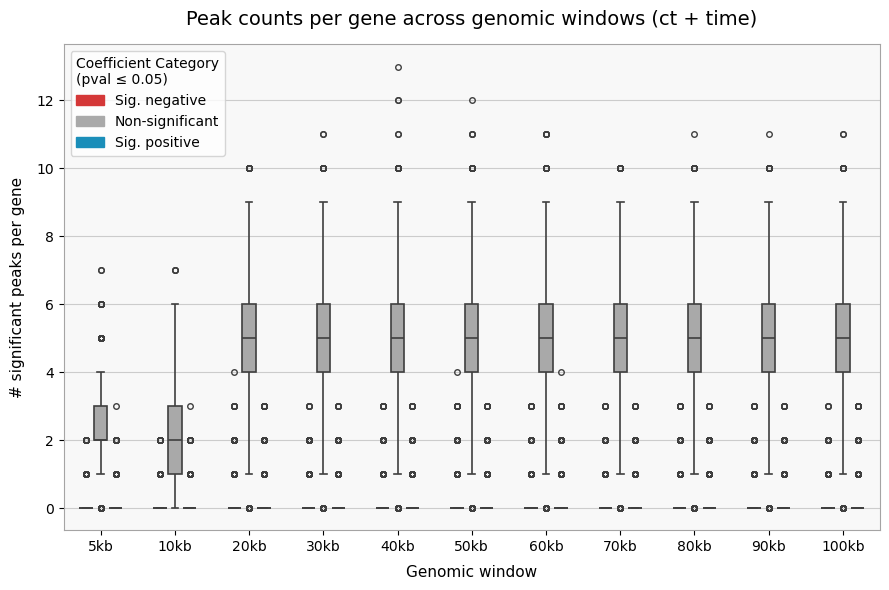

In [77]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=pair_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
#window_labels = {
#    "10kb":  "±TSS–10 kb",
#   "20kb":  "±10–20 kb",
#   "50kb":  "±20–50 kb",
#   "100kb": "±50–100 kb",
#}
#ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct + time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

KeyError: '5kb'

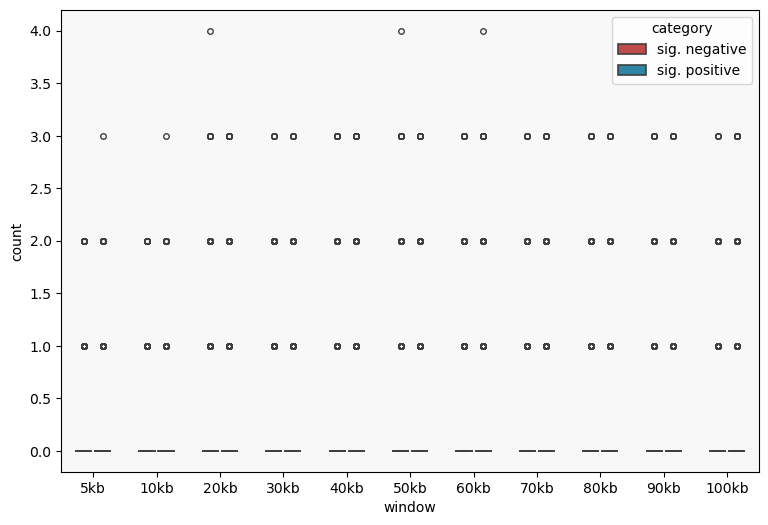

In [44]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct +time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

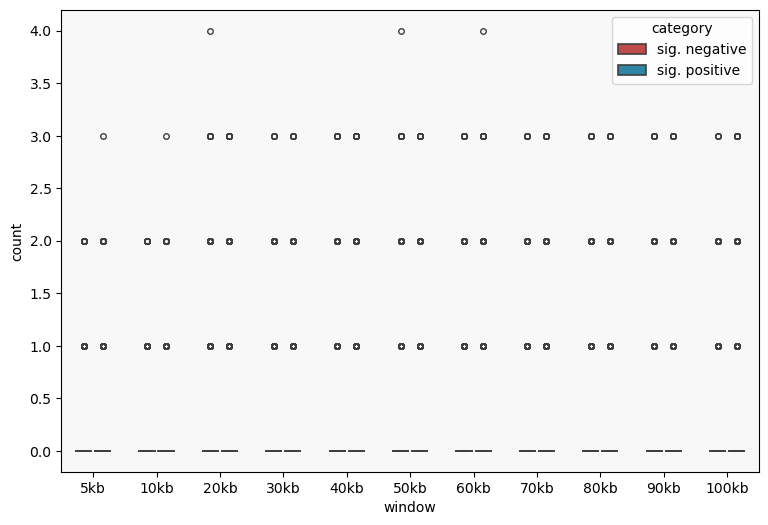

In [45]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window s

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns   

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")
sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "5kb":  "TSS–5kb",
    "10kb":  "-5kb–10kb",
    "20kb":  "-10–20kb",
    "30kb":  "-20–30kb",
    "40kb":  "-30–40kb",
    "50kb":  "-40–50kb",
    "60kb":  "-50–60kb",
    "70kb":  "-60–70kb",
    "80kb":  "-70–80kb",
    "90kb":  "-80–90kb",
    "100kb": "-90kb–100 kb",
}